In [12]:
import os
import sys
os.chdir('/zhome/71/c/146676/main/')
sys.path.append('/zhome/71/c/146676/main/')
import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import h5py
from sklearn.model_selection import train_test_split
from interactive_notebooks.n21_attachment import ThresholdedH5Dataset
from torch.utils.data import DataLoader, Dataset
from scipy.interpolate import interp1d
from numpy.linalg import lstsq
from scipy.optimize import nnls  # non-negative least squares
from sklearn.linear_model import Lasso
from tqdm.auto import tqdm  # ✅ Recommended for notebooks
import math
import importlib
from scipy.interpolate import interp1d
importlib.reload(sys.modules['interactive_notebooks.n21_attachment'])
from interactive_notebooks.n21_attachment import *

In [13]:
slice_index = 20

In [14]:
with h5py.File("/dtu-compute/msaca/sliceA_diffraction/abs_volume/overview_abs_volume.h5", "r") as f:
    # List all groups and datasets
    print("Keys:", list(f.keys()))
    
    # Access a dataset (replace 'dataset_name' with an actual name from the keys)
    dataset_abs = f["absorption"]
    DA_2 = dataset_abs[:,130:230]

absorption = DA_2[slice_index]
mask = absorption>0.002

Keys: ['absorption']


Processing /dtu-compute/msaca/sliceA_diffraction/powder-crystal/recons2-DA-0379.h5 with shape (667, 100, 362)
Total samples: 36200
Keys: ['absorption']


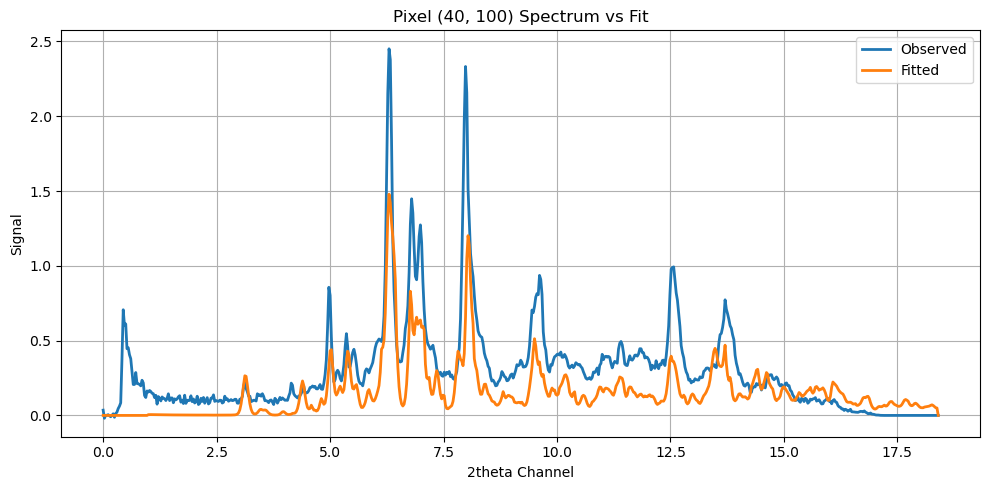

Name                      | Scaled Value
-----------------------------------------------------------------
Albite                    | 0.3361
Ferrosilite               | 0.2066
Enstatite                 | 0.1352
Diopside                  | 0.1344
Orthoclase                | 0.0762
Forsterite                | 0.0535
Magnetite                 | 0.0452
Rutile                    | 0.0124
Chlorapatite              | 0.0004


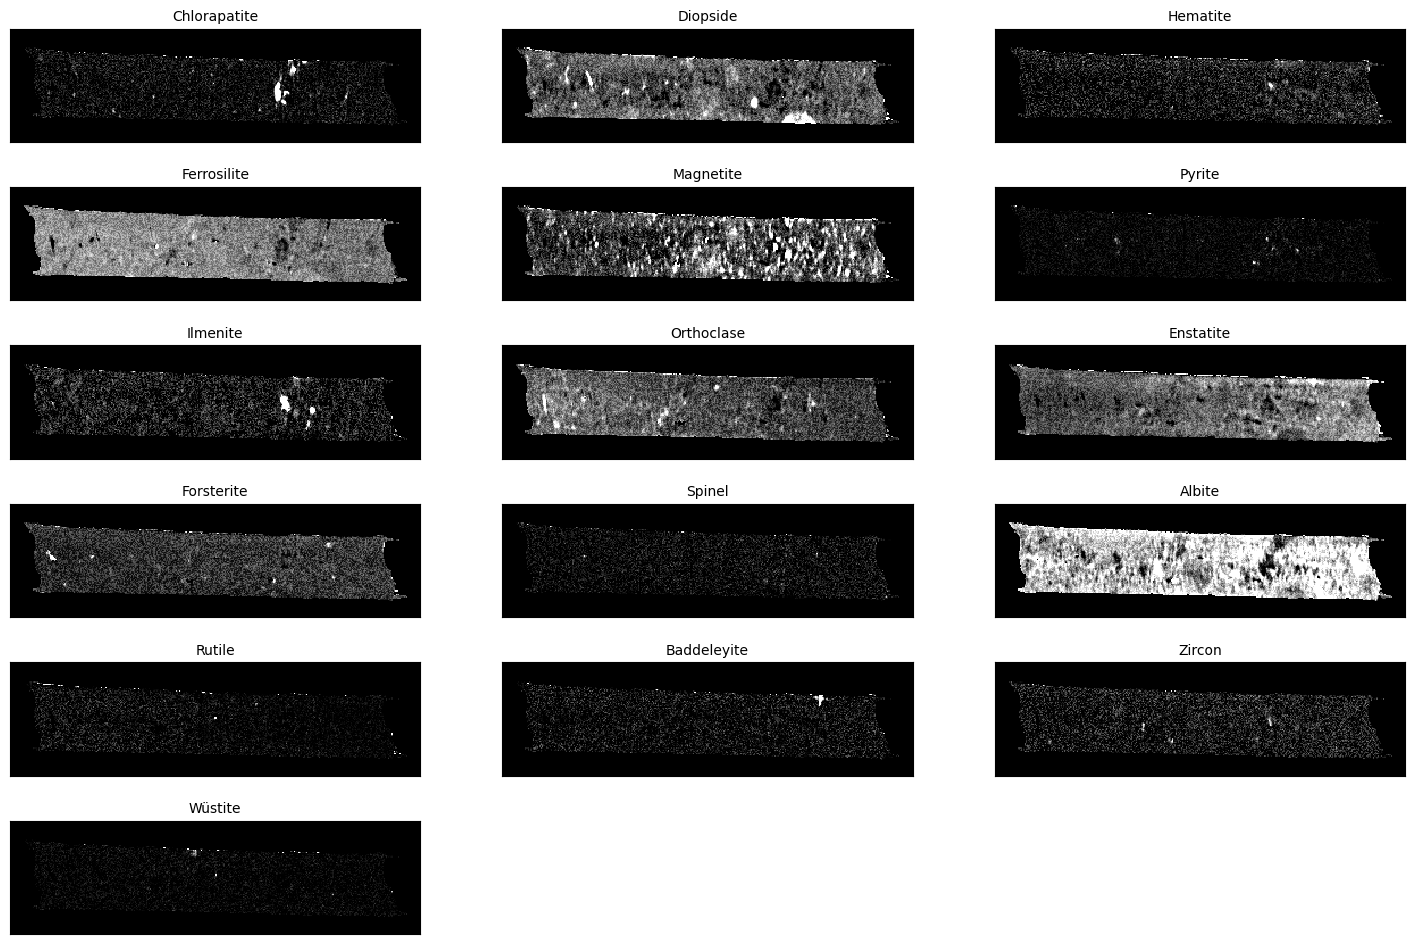

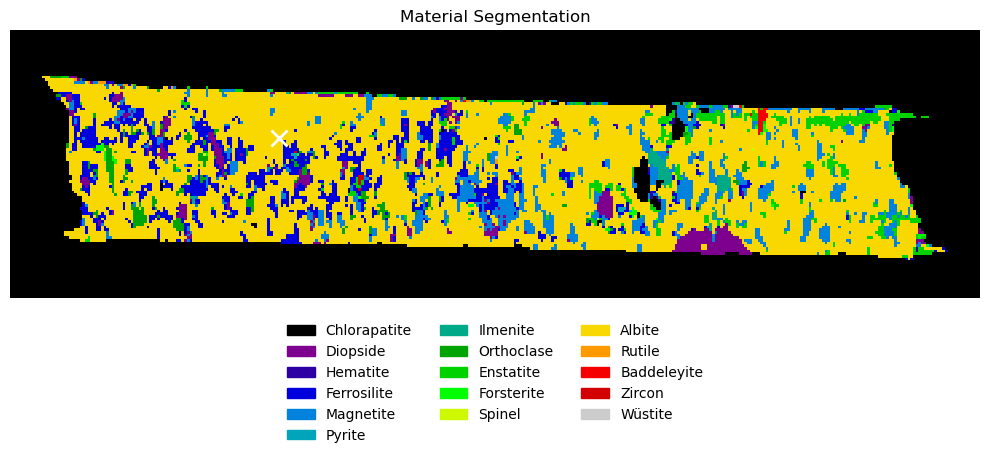

In [15]:
threshold = 3.5
theta_reg = False
data_dir = '/dtu-compute/msaca/sliceA_diffraction/powder-crystal'
index_list, all_files = get_index_list(data_dir, theta_reg = theta_reg, slice_index=20)
dataset = ThresholdedH5Dataset(index_list, threshold=threshold)
N_2theta = 667
w = np.ones(N_2theta)
w[:100] = 0
w[100:200] = 10



A,materials, materials_s, segm = complete_full_segmentation_analysis(dataset,
                                    all_files,
                                    num_blur=12,
                                    max_blur=6,
                                    method='GPU_Lasso',
                                    alpha=0.05,
                                    num_background=5,
                                    background_filter_sigma=None,
                                    box=None,
                                    w=w,
                                    j_global=40,
                                    k_global=100,
                                    N_2theta=N_2theta,
                                    display=True,
                                    slice_index = slice_index)

In [217]:
idx = dataset.index_list.index((all_files[0],50, 100))
print(np.sum(dataset[idx]))

200.0


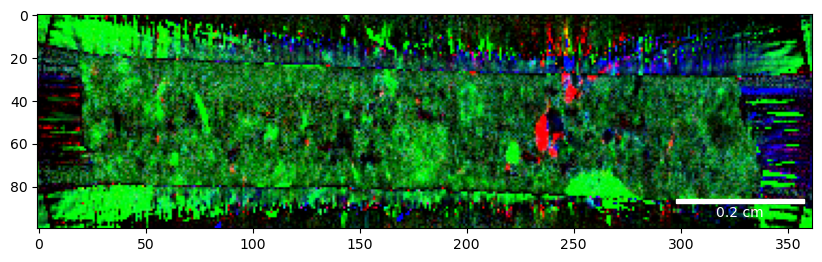

In [218]:
# Normalize each layer to [0, 1]
C = materials_s.copy()
norm_C = C / (C.max(axis=0, keepdims=True)+0.001)
rgb_image = np.stack([norm_C[0], norm_C[1], norm_C[2]], axis=-1)  # shape (i, j, 3)
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(rgb_image)
add_scalebar(ax, pixel_per_unit=60, length_in_units=1, label='0.2 cm')

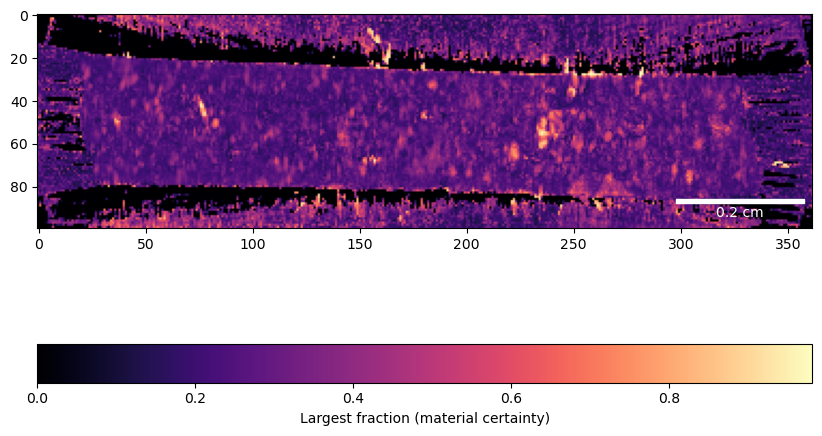

In [165]:

P = C.max(axis=0) / (C.sum(axis=0)+0.001)  # normalize over materials
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(P, cmap='magma')  # Save the mappable returned by imshow

fig.colorbar(im, ax=ax, label='Largest fraction (material certainty)', orientation='horizontal')

add_scalebar(ax, pixel_per_unit=60, length_in_units=1, label='0.2 cm')
plt.savefig('/dtu-compute/msaca/sliceA_diffraction/figures/2025_05_14_meeting/certainty.png', dpi=400, bbox_inches='tight')

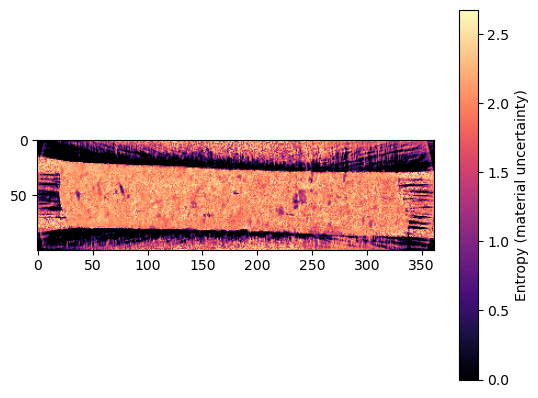

In [166]:
import numpy as np

P = C / (C.sum(axis=0, keepdims=True)+0.001)  # normalize over materials
entropy = -np.sum(P * np.log(P + 1e-12), axis=0)
plt.imshow(entropy, cmap='magma')
plt.colorbar(label='Entropy (material uncertainty)')


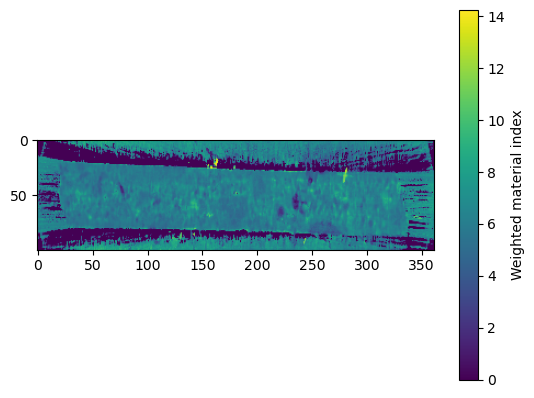

In [167]:
material_indices = np.arange(C.shape[0])[:, None, None]
soft_index = np.sum(P * material_indices, axis=0)
plt.imshow(soft_index, cmap='viridis')
plt.colorbar(label='Weighted material index')


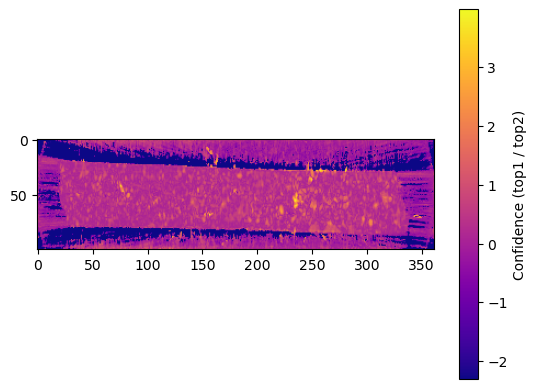

In [168]:
sorted_C = np.sort(C, axis=0)[::-1]  # descending
confidence = sorted_C[0] / (sorted_C[1] + 1e-3)
plt.imshow(np.log(confidence+0.1), cmap='plasma')
plt.colorbar(label='Confidence (top1 / top2)')


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.0].


0.0 2.0


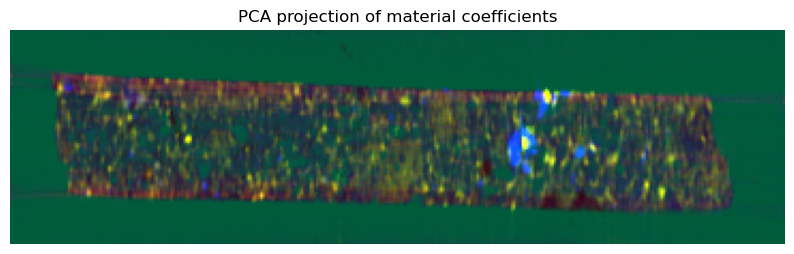

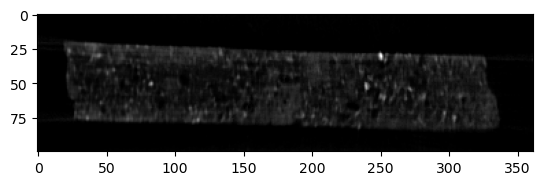

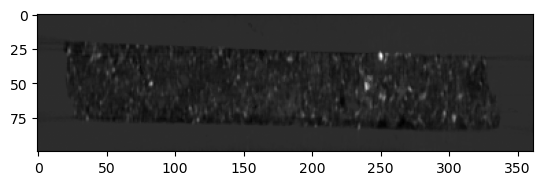

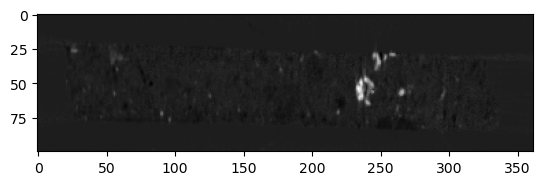

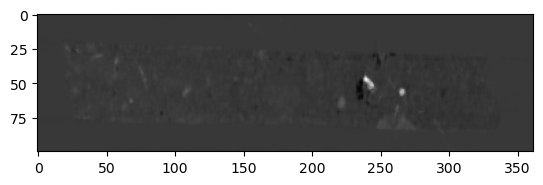

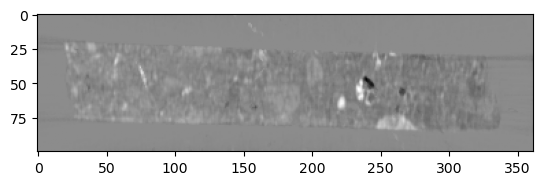

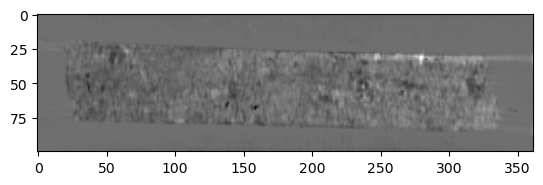

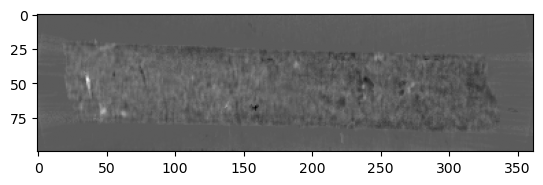

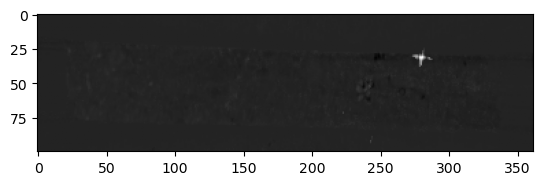

In [169]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Flatten spatial dimensions
plt.figure(figsize=(10, 5))
h, w = C.shape[1:]
C_flat = C.reshape(C.shape[0], -1).T  # shape: (num_pixels, 17)

# PCA to 3 components
pca = PCA(n_components=8)
C_pca = pca.fit_transform(C_flat)  # shape: (num_pixels, 3)

# Normalize to [0,1] for RGB
C_rgb = 2*(C_pca[:,0:3] - C_pca[:,0:3].min(axis=(0))) / (C_pca[:,0:3].ptp(axis=0) + 1e-10)

C_rgb_image = C_rgb.reshape(h, w, 3)
print(np.min(C_rgb_image), np.max(C_rgb_image))

plt.imshow(C_rgb_image)
plt.title("PCA projection of material coefficients")
plt.axis("off")
plt.show()


for i in range(8):
    plt.imshow(C_pca[:,i].reshape(h,w), cmap='gray')
    plt.show()



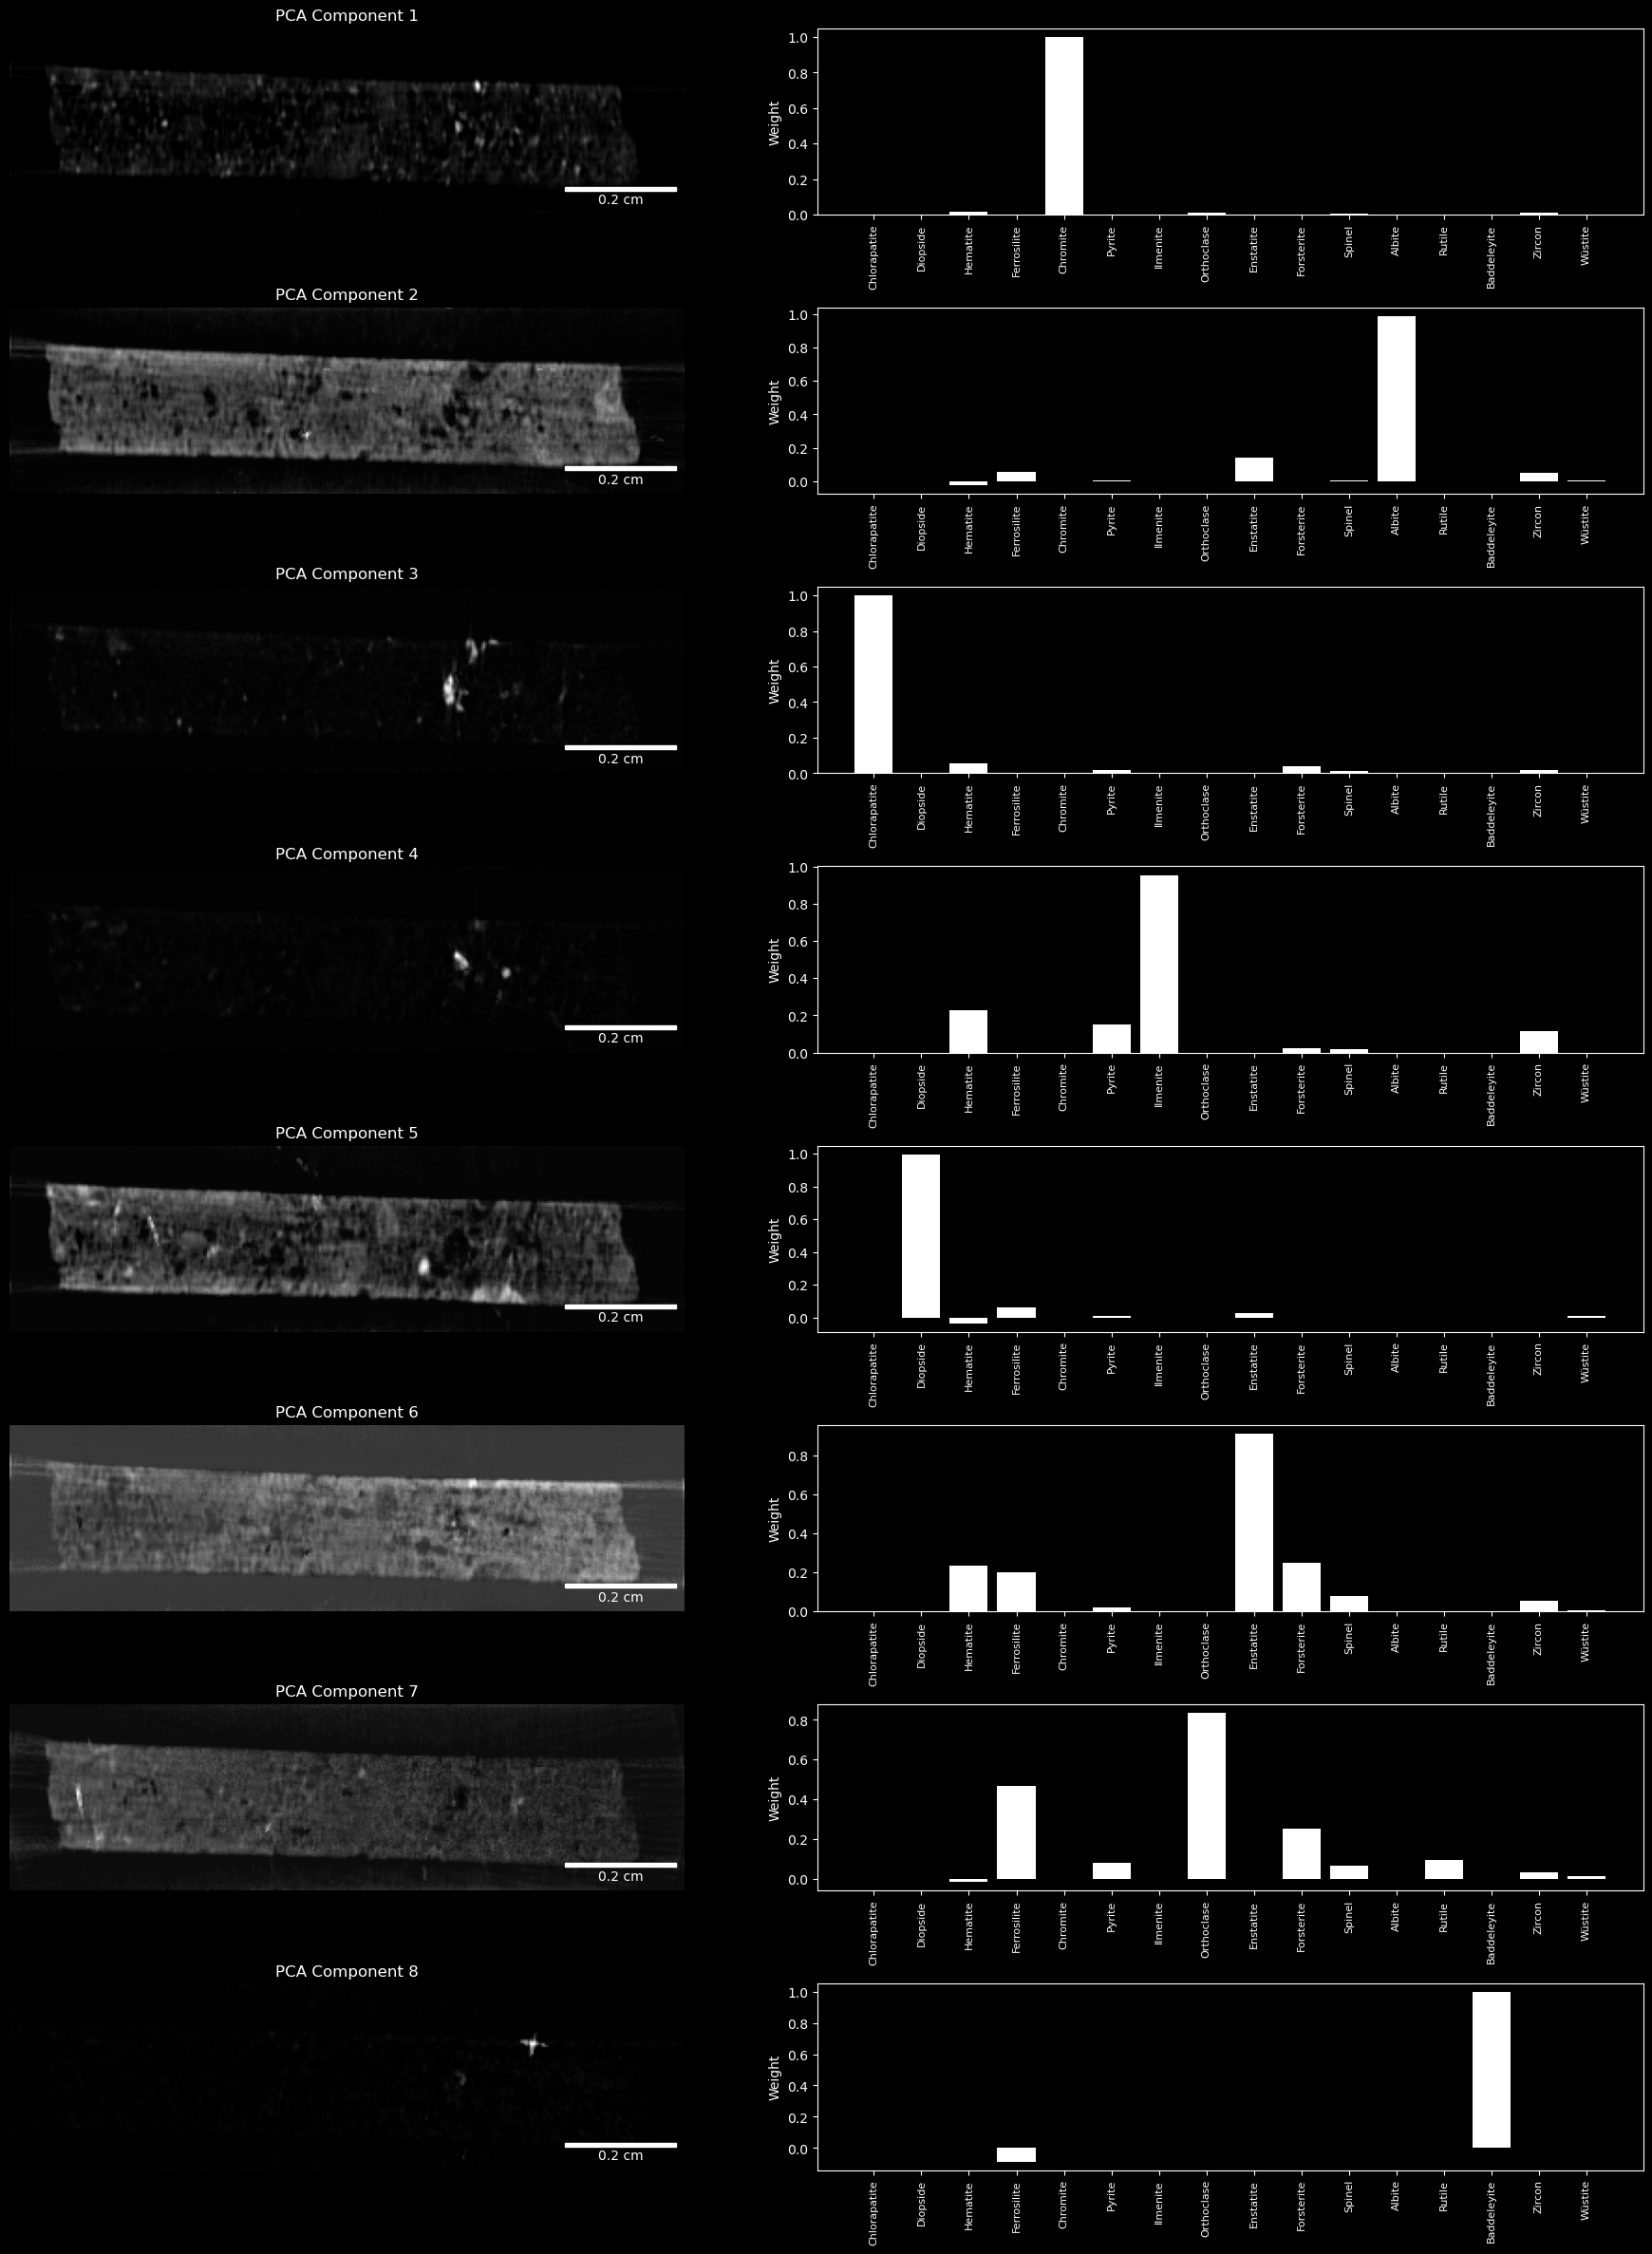

In [170]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import SparsePCA

spectra = load_xy_files('/dtu-compute/msaca/sliceA_diffraction/cif-files_and_theoretical_pd_spectra/PowderDiff_shortlist')
key_to_name = simplified_keys()
keys = spectra.keys()
keys = sorted(spectra.keys())
keys_simple = [key_to_name[k] for k in keys if k in key_to_name]
# Assumes: C (shape: [L, H, W]), keys_simple (length L)

# Flatten spatial dimensions
h, w = C.shape[1:]
C_flat = C.reshape(C.shape[0], -1).T  # shape: (num_pixels, L)

# PCA
alpha = 0.015
pca = SparsePCA(n_components=8, alpha = alpha)
C_pca = pca.fit_transform(C_flat)        # shape: (num_pixels, 8)
components = pca.components_             # shape: (8, L)

# Plot
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(20, 24), facecolor='black')
for i in range(8):
    # Left: spatial PCA map
    ax_img = axes[i, 0]
    ax_img.imshow(C_pca[:, i].reshape(h, w), cmap='gray')
    ax_img.set_title(f'PCA Component {i+1}', color='white')
    add_scalebar(ax_img, pixel_per_unit=60, length_in_units=1, label='0.2 cm')
    ax_img.axis('off')

    # Right: bar plot of PCA basis
    ax_bar = axes[i, 1]
    ax_bar.bar(np.arange(len(keys_simple)), components[i], color='white')
    ax_bar.set_xticks(np.arange(len(keys_simple)))
    ax_bar.set_xticklabels(keys_simple, rotation=90, fontsize=8, color='white')
    ax_bar.set_ylabel('Weight', color='white')
    ax_bar.tick_params(axis='y', colors='white')
    ax_bar.tick_params(axis='x', colors='white')
    ax_bar.spines['bottom'].set_color('white')
    ax_bar.spines['top'].set_color('white')
    ax_bar.spines['left'].set_color('white')
    ax_bar.spines['right'].set_color('white')
    ax_bar.set_facecolor('black')


# Global adjustments
plt.tight_layout()
plt.subplots_adjust(left=0.05, right=0.95, top=0.97, bottom=0.03)
plt.savefig('/dtu-compute/msaca/sliceA_diffraction/figures/2025_05_14_meeting/pca_plot.png', dpi=400, bbox_inches='tight')
plt.show()


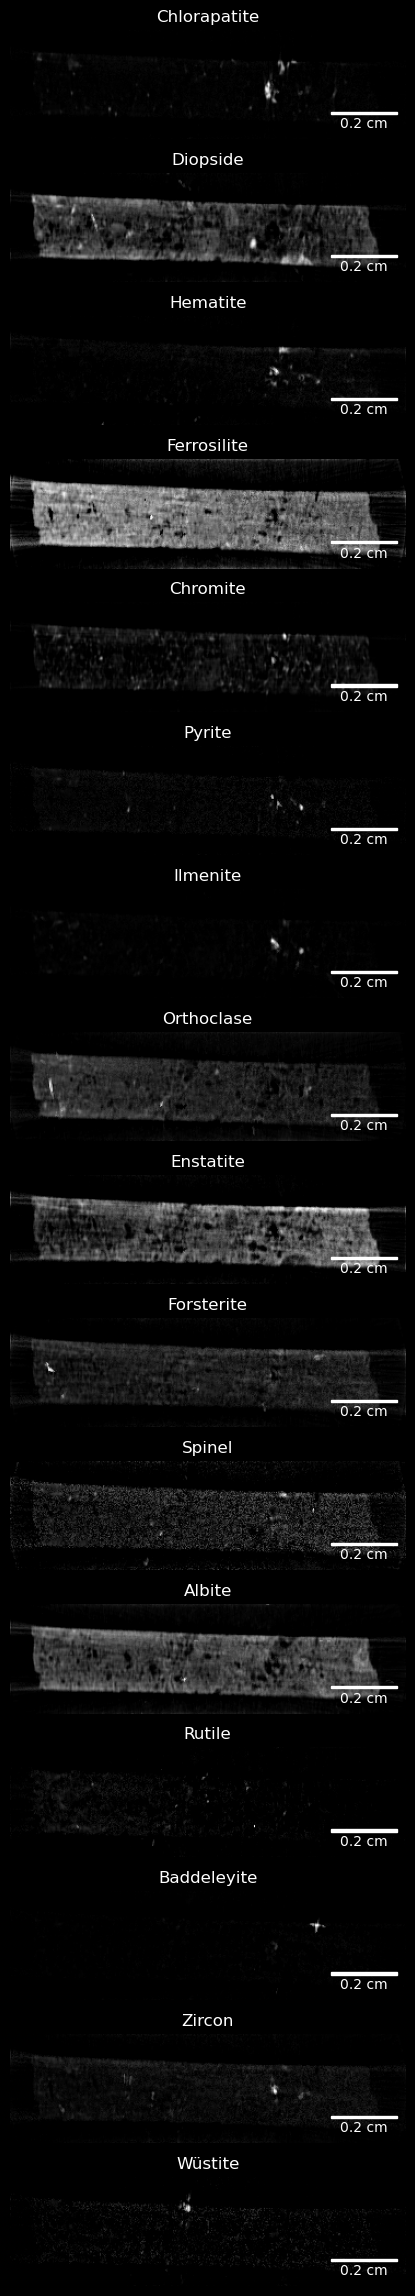

In [171]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import SparsePCA

spectra = load_xy_files('/dtu-compute/msaca/sliceA_diffraction/cif-files_and_theoretical_pd_spectra/PowderDiff_shortlist')
key_to_name = simplified_keys()
keys = spectra.keys()
keys = sorted(spectra.keys())
keys_simple = [key_to_name[k] for k in keys if k in key_to_name]
# Assumes: C (shape: [L, H, W]), keys_simple (length L)

# Flatten spatial dimensions
h, w = C.shape[1:]
C_flat = C.reshape(C.shape[0], -1).T  # shape: (num_pixels, L)

# PCA
alpha = 0.015
pca = SparsePCA(n_components=16, alpha = alpha)
C_pca = pca.fit_transform(C_flat)        # shape: (num_pixels, 8)
components = pca.components_             # shape: (8, L)

# Plot
fig, axes = plt.subplots(nrows=16, ncols=1, figsize=(20, 24), facecolor='black')
for i in range(16):
    # Left: spatial PCA map
    ax_img = axes[i]
    ax_img.imshow(C[i, :,:], cmap='gray')
    ax_img.set_title(keys_simple[i], color='white')
    add_scalebar(ax_img, pixel_per_unit=60, length_in_units=1, label='0.2 cm')
    ax_img.axis('off')



# Global adjustments
plt.tight_layout()
plt.subplots_adjust(left=0.05, right=0.95, top=0.97, bottom=0.03)
plt.savefig('/dtu-compute/msaca/sliceA_diffraction/figures/2025_05_14_meeting/material_plot.png', dpi=400, bbox_inches='tight')
plt.show()

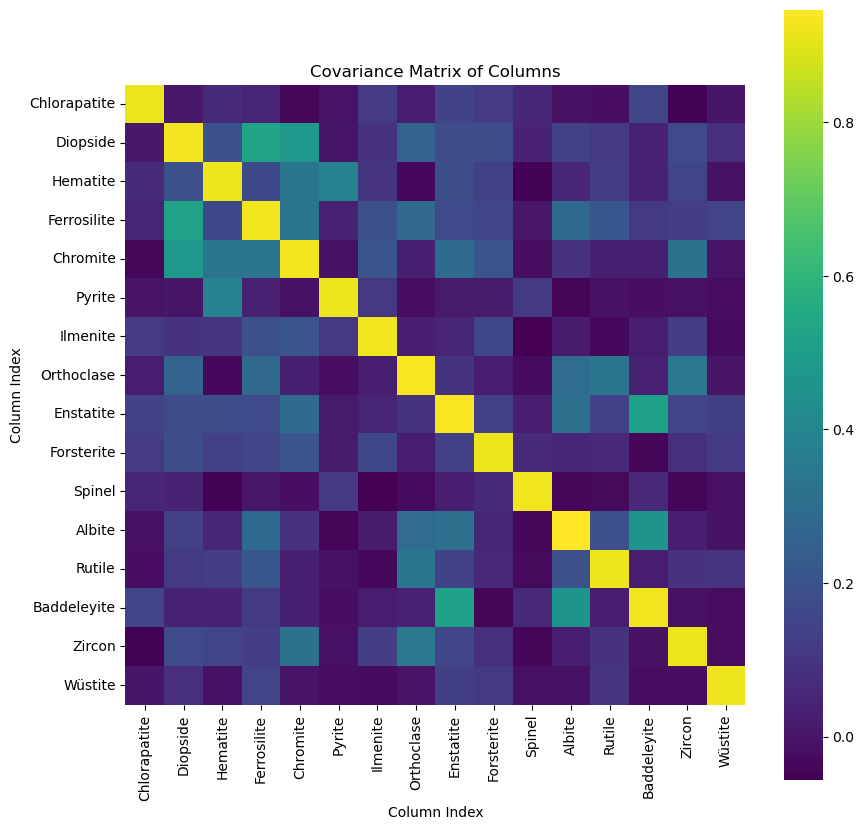

In [144]:
import seaborn as sns
num_background = 5
num_materials = 16
num_blur = 12
# Center the data (optional but common in covariance)
A_ = A[:,:-2*num_background]
A_centered = (A_ - A_.mean(axis=0))/A_.std(axis=0)

key_to_name = simplified_keys()
keys = spectra.keys()
keys = sorted(spectra.keys())
keys_simple = [key_to_name[k] for k in keys if k in key_to_name]
# Compute covariance matrix of columns
cov = np.cov(A_centered, rowvar=False)  # shape: (n_columns, n_columns)
# Assume M is your (174, 174) matrix, where 174 = 29 * 6
# Reshape into 4D: (29, 6, 29, 6)
cov_blocks = cov.reshape(num_materials, num_blur, num_materials, num_blur)

# Average over the 6×6 blocks (axes 1 and 3)
cov_collapsed = cov_blocks.mean(axis=(1, 3))  # shape: (29, 29)

plt.figure(figsize=(10, 10))
sns.heatmap(cov_collapsed, cmap="viridis", square=True, cbar=True,
            xticklabels=keys_simple, yticklabels=keys_simple)
#plt.imshow(cov_collapsed, cmap='viridis')
#plt.colorbar()
plt.title("Covariance Matrix of Columns")
plt.xlabel("Column Index")
plt.ylabel("Column Index")
plt.show()

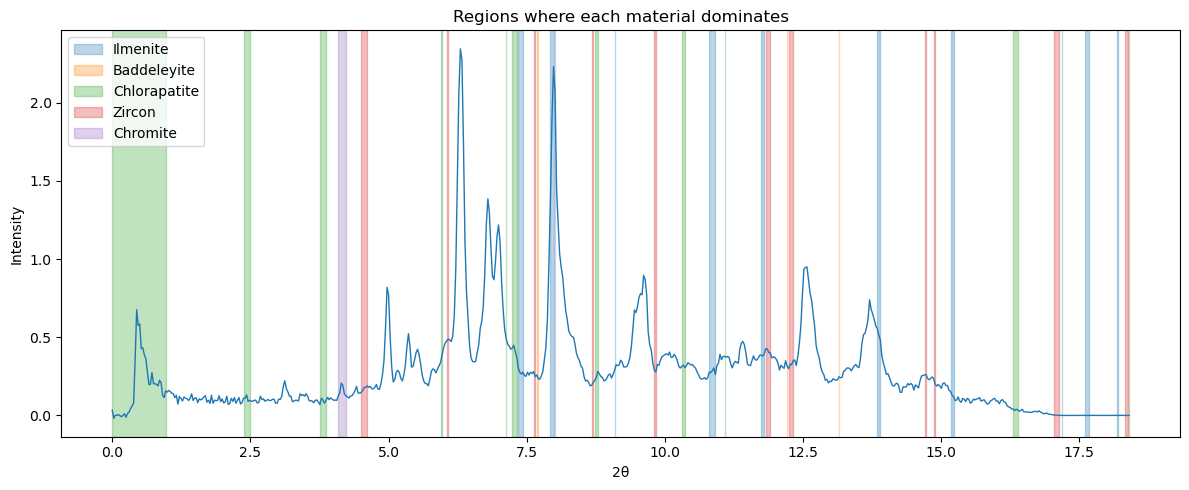

In [145]:
filename = all_files[0]
j_global = 40
k_global = 100
idx = dataset.index_list.index((filename,j_global, k_global))
y1 = dataset[idx]

idx = dataset.index_list.index((filename, j_global, k_global))

target_classes = ['Ilmenite', 'Baddeleyite', 'Chlorapatite', 'Zircon', 'Chromite']  # example
y = dataset[idx]
background_filter_sigma = None
num_background = 5
num_blur = 12
if background_filter_sigma is None:
    A_subset = A[:,7:-2*num_background:num_blur]
else:
    A_subset = A[:,7::num_blur]

twotheta = np.linspace(0, 18.4, 667)

A_max = np.max(A_subset,axis=1)/(np.sum(A_subset,axis=1)+0.0001)
A_argmax = np.argmax(A_subset,axis=1)
peak_plot(target_classes, [y], A_argmax, keys_simple, twotheta)

['Chlorapatite', 'Diopside', 'Hematite', 'Ferrosilite', 'Chromite', 'Pyrite', 'Ilmenite', 'Orthoclase', 'Enstatite', 'Forsterite', 'Spinel', 'Albite', 'Rutile', 'Baddeleyite', 'Zircon', 'Wüstite']


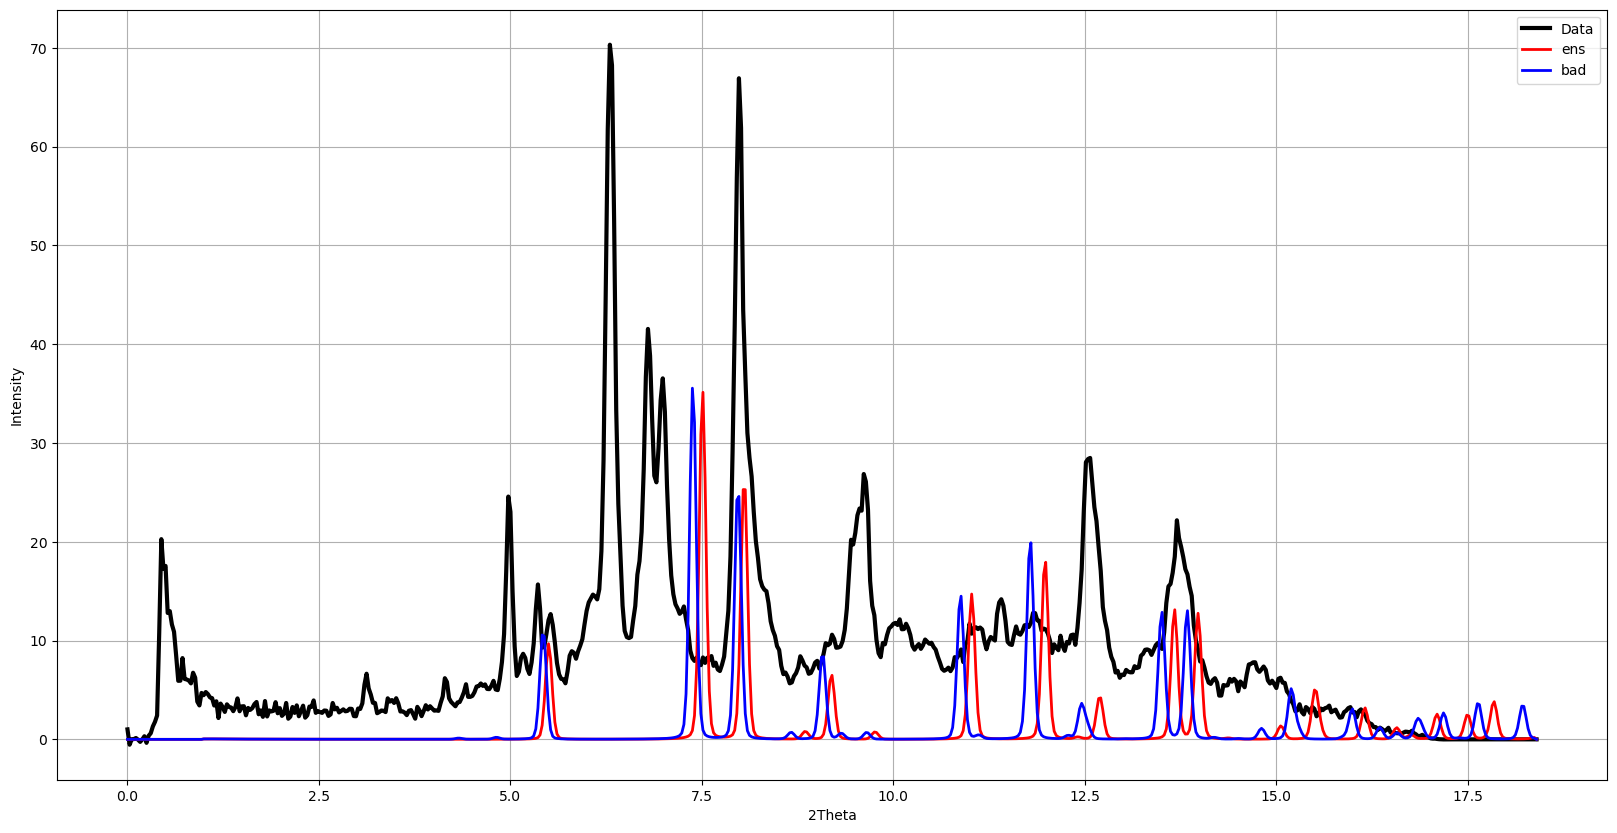

In [161]:
plt.figure(figsize=(20, 10))
print(keys_simple)
plt.plot(twotheta, 30*y, label='Data', color='black', linewidth=3)
plt.plot(twotheta, A_subset[:,2], color='red', label='ens', linewidth=2)
plt.plot(twotheta, A_subset[:,6], color='blue', label='bad', linewidth=2)

plt.legend()
plt.xlabel('2Theta')
plt.ylabel('Intensity')
plt.grid()
plt.savefig('/dtu-compute/msaca/sliceA_diffraction/figures/2025_05_14_meeting/data.png', dpi=400, bbox_inches='tight')
plt.show()

In [147]:
def orthogonalize_groups(A, groups):
    A = A.copy()
    groups = np.asarray(groups)
    unique_groups = np.unique(groups)

    for g in unique_groups:
        if g == 0:
            continue  # Skip orthogonalization for group 0

        group_indices = np.where(groups == g)[0]
        A_group = A[:, group_indices]

        # SVD decomposition
        U, S, Vt = np.linalg.svd(A_group, full_matrices=False)

        # Replace the original columns with orthogonal ones (not normalized)
        A[:, group_indices] = U @ np.diag(S)

    return A

(667, 202)
(667, 202)
(667, 192)
(667, 202)
[ 1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+

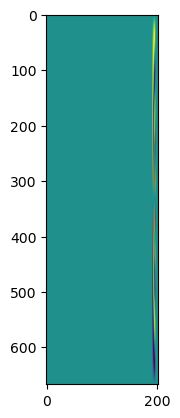

In [148]:
print(A.shape)
groups = np.zeros(np.shape(A)[1])
groups[1*num_blur:2*num_blur] = 1
groups[3*num_blur:4*num_blur] = 1

print(A.shape)
A_ = A[:,:-2*num_background]/(np.sum(A[:,:-2*num_background],axis=0))
print(A_.shape)
A_ = add_fourier_background_basis(A_, np.linspace(0,18.4,N_2theta), num_frequencies=num_background, reletive_weight = 0.5)
print(A_.shape)
A_q = orthogonalize_groups(A_,groups)
print(np.sum(A_n,axis=0))

plt.imshow(A_n)
N_2theta = 667
w = np.ones(N_2theta)
materials1 = fit_all_pixels(dataset, A_q, alpha = 0.00005, background_filter_sigma=None, method='GPU_Lasso', w=w)


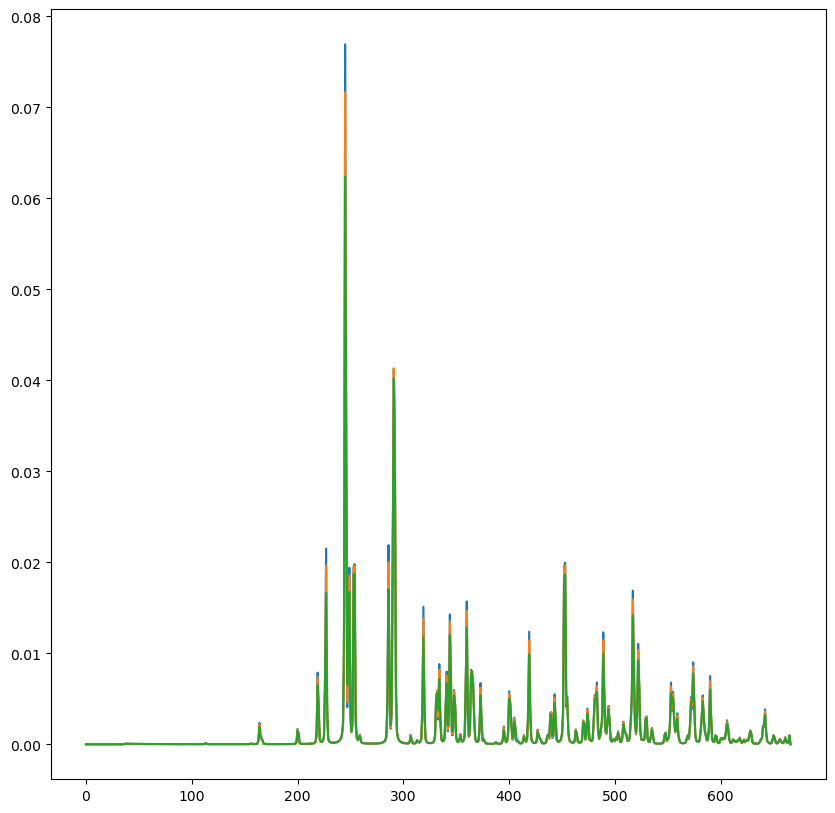

In [149]:
ny = 100
nx = 362
materials1_ = materials1[:-(2*num_background)]
materials1_4d = materials1_.reshape(num_materials, num_blur, ny, nx)
materials1_summed = materials1_4d.sum(axis=1)


#plt.figure(figsize=(10,10))
#plt.imshow(A-A_)
#plt.show()

plt.figure(figsize=(10,10))
plt.plot(A_[:,1*num_blur])
plt.plot(A_[:,1*num_blur+1])
plt.plot(A_[:,1*num_blur+2])
plt.show()

/dtu-compute/msaca/conda3/envs/cil6/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:753: ConvergenceWarning: Early stopping the lars path, as the residues are small and the current value of alpha is no longer well controlled. 20 iterations, alpha=1.827e-06, previous alpha=1.821e-06, with an active set of 13 regressors.
  warnings.warn(


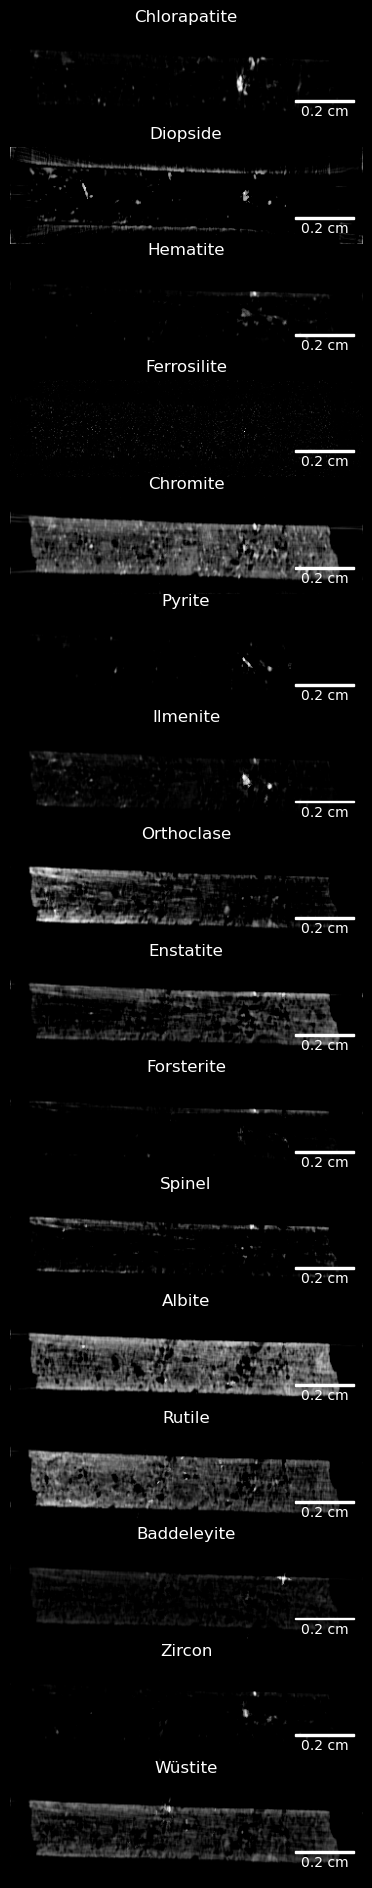

In [150]:
C = materials1_summed.copy()
spectra = load_xy_files('/dtu-compute/msaca/sliceA_diffraction/cif-files_and_theoretical_pd_spectra/PowderDiff_shortlist')
key_to_name = simplified_keys()
keys = spectra.keys()
keys = sorted(spectra.keys())
keys_simple = [key_to_name[k] for k in keys if k in key_to_name]
# Assumes: C (shape: [L, H, W]), keys_simple (length L)

# Flatten spatial dimensions
h, w = C.shape[1:]
C_flat = C.reshape(C.shape[0], -1).T  # shape: (num_pixels, L)

# PCA
alpha = 0.015
pca = SparsePCA(n_components=16, alpha = alpha)
C_pca = pca.fit_transform(C_flat)        # shape: (num_pixels, 8)
components = pca.components_             # shape: (8, L)

# Plot
fig, axes = plt.subplots(nrows=16, ncols=1, figsize=(20, 24), facecolor='black')
for i in range(16):
    # Left: spatial PCA map
    ax_img = axes[i]
    ax_img.imshow(C[i, :,:], cmap='gray')
    ax_img.set_title(keys_simple[i], color='white')
    add_scalebar(ax_img, pixel_per_unit=60, length_in_units=1, label='0.2 cm')
    ax_img.axis('off')


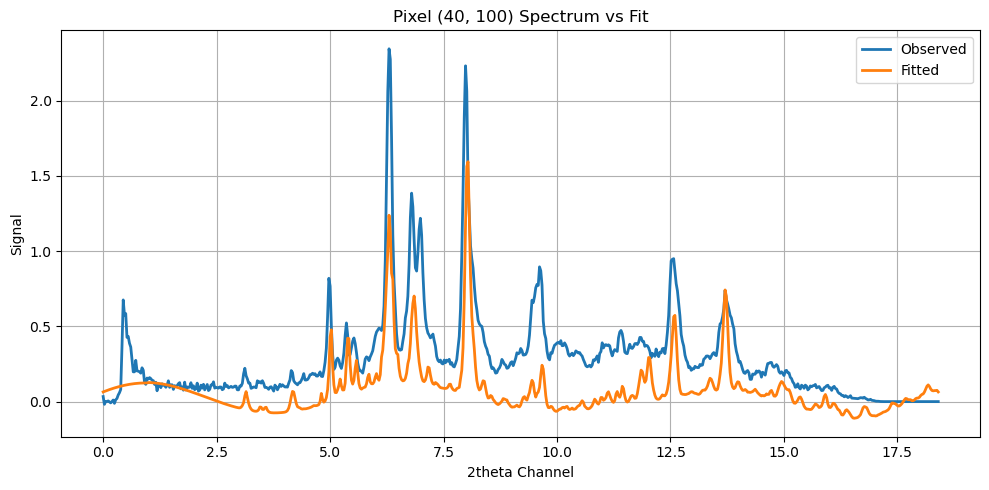

In [151]:
plot_pixel_fit(j_global=j_global, k_global=k_global, dataset=dataset, materials=materials1,
               A=A_,box = [0,100,0,362], filename=all_files[0], background_filter_sigma=background_filter_sigma)